In [14]:
#Импорт

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Input

In [15]:
#Задаем значения

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    shuffle=True,
    stratify=y_train,
    random_state=42
)

In [16]:
#Создание модели

model = Sequential([
    # === БЛОК 0: ВХОД ===
    Input(shape=(28, 28, 1)),

    # === БЛОК 1: АУГМЕНТАЦИЯ ===
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),

    # === БЛОК 2: СВЕРТОЧНЫЙ СЛОЙ 1 ===
    Conv2D(32, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    Conv2D(32, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    MaxPooling2D(2),

    # === БЛОК 3: СВЕРТОЧНЫЙ СЛОЙ 2 ===
    Conv2D(64, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    Conv2D(64, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.GlobalAveragePooling2D(),

    # === БЛОК 4: КЛАССИФИКАТОР ===
    Dense(128, activation='relu'),
    Dropout(0.5),

    # === БЛОК 5: ВЫХОД ===
    Dense(10, activation='softmax')
])

In [17]:
#Обучение модели

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cd = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('model.keras', save_best_only=True, verbose=1),
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=cd
)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Честный результат: {test_accuracy:.4f}, {test_loss:.4f}")

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6926 - loss: 0.9753
Epoch 1: val_loss improved from None to 0.67634, saving model to model.keras

Epoch 1: finished saving model to model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 110s 138ms/step - accuracy: 0.8503 - loss: 0.5057 - val_accuracy: 0.7857 - val_loss: 0.6763 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9539 - loss: 0.1624
Epoch 2: val_loss did not improve from 0.67634
750/750 ━━━━━━━━━━━━━━━━━━━━ 104s 138ms/step - accuracy: 0.9576 - loss: 0.1478 - val_accuracy: 0.6667 - val_loss: 1.0700 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9655 - loss: 0.1222
Epoch 3: val_loss did not improve from 0.67634
750/750 ━━━━━━━━━━━━━━━━━━━━ 106s 142ms/step - accuracy: 0.9680 - loss: 0.1131 - val_accuracy: 0.7425 - val_loss: 0.8596 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9730 - loss: 0.

Эпоха 1: val_loss = 0.6763
Эпоха 2: val_loss = 1.0700
Эпоха 3: val_loss = 0.8596
Эпоха 4: val_loss = 0.4559
Эпоха 5: val_loss = 0.2292
Эпоха 6: val_loss = 1.7097
Эпоха 7: val_loss = 0.4145
Эпоха 8: val_loss = 0.1107
Эпоха 9: val_loss = 0.2797
Эпоха 10: val_loss = 0.2908
Эпоха 11: val_loss = 0.1321
Эпоха 12: val_loss = 0.0572
Эпоха 13: val_loss = 0.0670
Эпоха 14: val_loss = 0.0390
Эпоха 15: val_loss = 0.0410
Эпоха 16: val_loss = 0.0629
Эпоха 17: val_loss = 0.0642
Эпоха 18: val_loss = 0.0550
Эпоха 19: val_loss = 0.0344
Эпоха 20: val_loss = 0.0398


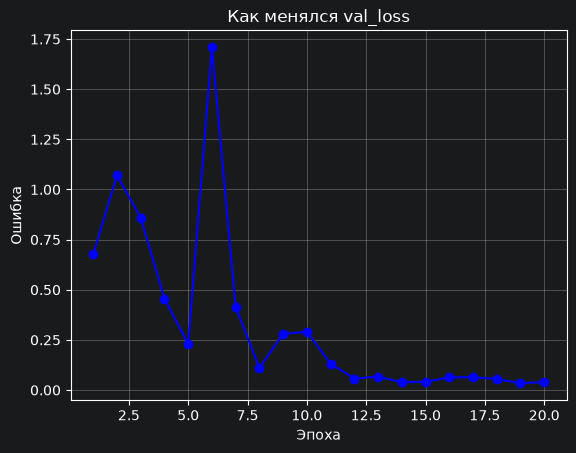

In [18]:
# Смотрим историю
val_loss = history.history['val_loss']
epochs = range(1, len(val_loss) + 1)

# Печатаем каждую эпоху
for i, loss in enumerate(val_loss, 1):
    print(f"Эпоха {i}: val_loss = {loss:.4f}")

# Рисуем график
plt.plot(epochs, val_loss, 'b-o', label='val_loss')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.title('Как менялся val_loss')
plt.grid(True)
plt.show()